In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
PROCESSED_DIR = Path("../../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "london_weekdays_treino.csv"
test_path = PROCESSED_DIR / "london_weekdays_teste.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print(df_train.shape, df_test.shape)


(3691, 13) (923, 13)


In [6]:
TARGET = "realSum"


X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]


X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [7]:
def analise_hiperparametros(features, target):

    search_space = {
        "n_estimators": Integer(400, 1000),
        "learning_rate": Real(0.05, 0.1, prior="log-uniform"),
        "max_depth": Integer(3, 8),
        "min_child_weight": Integer(1, 10),
        "subsample": Real(0.7, 1.0),
        "colsample_bytree": Real(0.7, 1.0),
        "gamma": Real(0, 1),
        "reg_alpha": Real(0, 0.5),
        "reg_lambda": Real(0.1, 10)
    }

    opt = BayesSearchCV(
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        search_spaces=search_space,
        n_iter=60,         
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True
    )

    opt.fit(features, target)
    return opt


In [8]:
grid = analise_hiperparametros(X_train, y_train)

best_model = grid.best_estimator_

print("Melhores hiperparâmetros:")
print(grid.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [18]:
results = grid.cv_results_
y_pred = best_model.predict(X_test)

fold_std_across_iterations = {}

for i in range(5):
    fold_scores = results[f"split{i}_test_score"]
    fold_std_across_iterations[f"fold_{i}"] = np.std(fold_scores)

for i in range(5):
    print(f'fold_{i} : {fold_std_across_iterations[f"fold_{i}"]:2f}')



fold_0 : 0.035700
fold_1 : 0.029519
fold_2 : 0.035564
fold_3 : 0.045081
fold_4 : 0.037896


In [19]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0043
RMSE: 0.0655
R²  : 0.7026


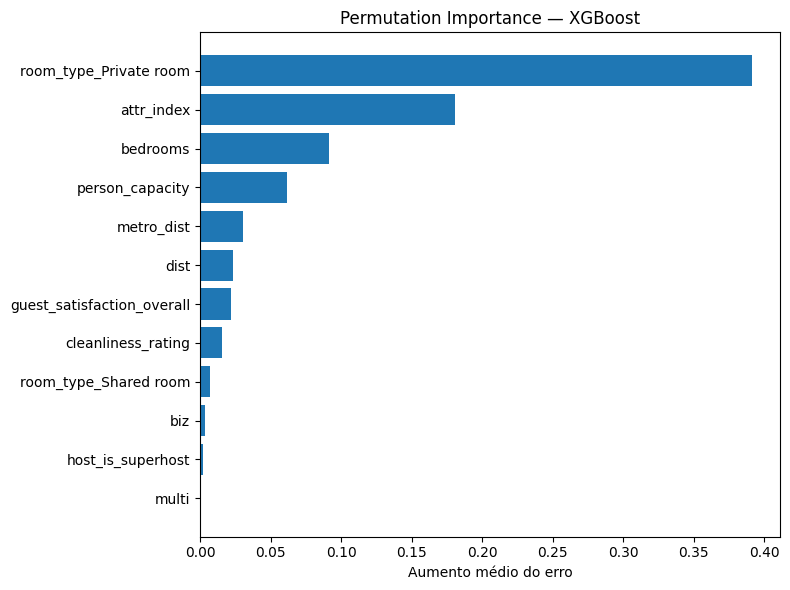

In [20]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean,
            index=X_test.columns).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(perm_imp.index[-15:], perm_imp.values[-15:])
plt.xlabel("Aumento médio do erro")
plt.title("Permutation Importance — XGBoost")
plt.tight_layout()
plt.show()
